Importing Libraries and LLM Setup

In [1]:
from langchain_core.prompts import PromptTemplate
from pydantic import BaseModel, Field
from typing import List, Dict, Literal
from langgraph.graph import StateGraph, END

In [2]:
import os
import sys
sys.path.append(os.path.abspath(".."))

In [3]:
from agent.llm import call_llm, call_structured_llm
from agent.states import GlobalState

In [4]:
# Common example input aligned with GlobalState and planning/design schemas
common_validation_state = {
    "requirements": {
        "problem": "Build a social app for pet owners to share updates and photos",
        "users": ["pet owners", "pet enthusiasts"],
        "features": [
            "user authentication",
            "pet profiles",
            "photo uploads",
            "social feed",
            "follow connections",
            "notifications"
        ],
        "scale_hint": "~10,000 DAU",
        "domain": "social_media"
    },
    "constraints": {
        "scale": "10k daily active users",
        "latency": "p95 under 200ms for core read APIs",
        "budget": "moderate",
        "team_size": "small",
        "security": "JWT auth, encrypted storage, OWASP basics"
    },
    "architecture": {
        "pattern": "microservices",
        "modules": [
            "auth",
            "pet-profile",
            "media",
            "feed",
            "social-graph",
            "notifications"
        ],
        "reasoning": "Independent scaling for feed and media services with clear bounded contexts.",
        "confidence": 0.83
    },
    "tech_stack": {
        "frontend": {
            "language": "TypeScript",
            "framework": "Next.js",
            "reasoning": "SSR plus a strong React ecosystem for fast UI delivery."
        },
        "backend": {
            "language": "Python",
            "framework": "FastAPI",
            "api_style": "REST",
            "reasoning": "Fast development, async support, and clean schema-based APIs."
        },
        "database": {
            "type": "relational",
            "name": "PostgreSQL",
            "orm": "SQLAlchemy",
            "reasoning": "Strong consistency for user, feed, and relationship data."
        },
        "infra": {
            "provider": "AWS",
            "services": ["EKS", "RDS", "S3", "CloudFront"],
            "reasoning": "Managed compute, durable storage, and scalable delivery."
        },
        "overall_reasoning": "Stack is aligned with microservices, moderate budget, and target scale.",
        "confidence": 0.86
    },
    "design_bundle": {
		"services": {
			"services": [
				{
					"name": "auth-service",
					"responsibility": "Authentication and token management",
					"owned_data": ["users", "sessions"],
					"dependencies": [],
					"key_patterns": "JWT + refresh token rotation"
				},
				{
					"name": "feed-service",
					"responsibility": "Timeline and post retrieval",
					"owned_data": ["posts", "reactions"],
					"dependencies": ["social-graph-service", "media-service"],
					"key_patterns": "fan-out on write + caching"
				}
			],
			"reasoning": "Clear separation of concerns with minimal dependencies for core services.",
			"confidence": 0.88
		},
        "database_schema": {
            "tables": [
                {
                    "name": "users",
                    "description": "Registered user accounts",
                    "fields": ["id: uuid, pk", "email: varchar", "password_hash: varchar"],
                    "relations": []
                },
                {
                    "name": "pets",
                    "description": "Pet profiles owned by users",
                    "fields": ["id: uuid, pk", "owner_id: uuid, fk", "name: varchar", "species: varchar"],
                    "relations": ["pets.owner_id -> users.id"]
                },
                {
                    "name": "photos",
                    "description": "Pet media metadata",
                    "fields": ["id: uuid, pk", "pet_id: uuid, fk", "s3_key: varchar", "created_at: timestamp"],
                    "relations": ["photos.pet_id -> pets.id"]
                }
            ],
            "reasoning": "Normalized core entities with explicit ownership and relations.",
            "confidence": 0.9
        },
        "api_endpoints": {
			"api_endpoints": [
				{"name": "Create User", "purpose": "Register a new user", "base_route": "/api/users"},
				{"name": "Create Pet Profile", "purpose": "Create a pet profile", "base_route": "/api/pets"},
				{"name": "Upload Photo", "purpose": "Upload pet photos", "base_route": "/api/photos"}
			],
			"frontend_notes": "Endpoints are designed around core entities and user actions.",
			"reasoning": "Endpoints are designed around core entities and user actions.",
			"confidence": 0.87
		},
        "infrastructure": {
            "cloud": "AWS",
            "services": ["EKS", "RDS (PostgreSQL)", "S3", "CloudFront"],
            "deployment": "Dockerized services on EKS with managed PostgreSQL and object storage.",
            "reasoning": "Managed services reduce ops burden and support scaling.",
            "confidence": 0.87
        }
    }
}

### Validation Stage
1. Requirements Alignment: Check if the design meets the specified requirements and constraints.
2. Cross-Component Validation: Ensure that the design is consistent across different components and modules.
3. Decision Optimization: Suggest improvements to the design based on available alternatives and constraints.
4. Scoring: Develop a scoring mechanism to evaluate the design based on confidence factors and validation results.

In [5]:
# ========= Validation Graph States ========

class ValidationState(GlobalState):
	req_align_report: Dict
	cross_component_report: Dict
	decision_optimizations: Dict
	scoring_report: Dict[str, float]

In [6]:
# ============= Validation Nodes ============

# Validation Output Schemas

class IssueSchema(BaseModel):
    issue_name: str
    description: str = Field(description="Concise explanation of the issue identified in the design")
    component: Literal["architecture", "tech_stack", "services", "database_design", "api_design", "infrastructure"]
    severity: Literal["low", "medium", "high"]

class ValidationReport(BaseModel):
    issues: List[IssueSchema] = Field(default_factory=list)
    total_checks: int = Field(default=0, description="Total number of validation checks performed across all components.")
    confidence: float = Field(default=0.0, description="Confidence score between 0 and 1, representing the likelihood that the identified issues are valid and relevant to the design.")

class ValidationOutput(BaseModel):
    validation_report: ValidationReport

In [7]:
# Base prompt template for all validations (LLM Critic)

validate_prompt = PromptTemplate.from_template(
    """You are a software architecture evaluator.
Your task is to analyze the given INPUT and identify issues based on the VALIDATION GOAL.
Also, count the total number of validation checks performed across all components to provide context on the thoroughness of the evaluation.

Focus only on meaningful issues. Avoid generic or obvious statements.

{validation_details}

IMPORTANT:
- Do NOT hallucinate missing components.
- Avoid potential improvements or suggestions if current design is correct.
- Do NOT repeat same issue
- Be precise and technical""")

In [8]:
# Requirements Alignment Prompt Templates

# Requirements -> Architecture + Services
req_arch_services_prompt = PromptTemplate.from_template(
	"""VALIDATION GOAL:
Check if the architecture and services align with the specified requirements.

Identify:
- Missing services
- Missing capabilities
- Architectural mismatches
- Incorrect mapping of features
       
INPUT:
Requirements:
{requirements}

Architecture:
{architecture}

Services:
{services}
"""
)

# Constraints -> Architecture + Tech Stack
constr_arch_stack_prompt = PromptTemplate.from_template(
	"""VALIDATION GOAL:
Check if the architecture and tech stack choices align with the specified constraints.

Identify:
- Violations of constraints
- Risky or incompatible decisions

INPUT:
Constraints:
{constraints}

Architecture:
{architecture}

Tech Stack:
{tech_stack}
"""
)

# # Requirements + Constraints -> Architecture + Infrastructure
# req_constr_arch_infra_prompt = PromptTemplate.from_template(
# 	"""VALIDATION GOAL:
# Check if the architecture and infrastructure choices align with the specified requirements and constraints.

# Identify:
# - Missing or misaligned infrastructure components
# - Violations of requirements or constraints

# INPUT:
# Requirements:
# {requirements}

# Constraints:
# {constraints}

# Architecture:
# {architecture}

# Infrastructure:
# {infrastructure}
# """
# )

In [9]:
# Node function for requirements alignment validation
def requirements_alignment_node(state: ValidationState):
	requirements = state.get("requirements", {})
	constraints = state.get("constraints", {})
	architecture = state.get("architecture", {})
	tech_stack = state.get("tech_stack", {})
	services = state.get("design_bundle", {}).get("services", {})
	infrastructure = state.get("design_bundle", {}).get("infrastructure", {})
    
	requirement_alignment_prompt_details = [
		req_arch_services_prompt.format(
			requirements=requirements,
			architecture=architecture,
			services=services
		),
		constr_arch_stack_prompt.format(
			constraints=constraints,
			architecture=architecture,
			tech_stack=tech_stack
		),
	]
		
	req_align_issues = []
	total_checks = 0
	total_confidence = 0
	
	for detail in requirement_alignment_prompt_details:
		prompt = validate_prompt.format(validation_details=detail)
		result = call_structured_llm(ValidationOutput, prompt)

		issues_list = result.get("validation_report", {}).get("issues", [])
		total_checks += result.get("validation_report", {}).get("total_checks", 0)
		total_confidence += result.get("validation_report", {}).get("confidence", 0)
		req_align_issues.extend(issues_list)

	req_align_report = {
		"issues": req_align_issues,
		"total_checks": total_checks,
		"confidence": total_confidence / len(requirement_alignment_prompt_details)
	}
		
	return {
        "req_align_report": req_align_report
    }

In [10]:
# Example Usage for requirements alignment validation node
req_align_output = requirements_alignment_node(common_validation_state)
req_align_output

{'req_align_report': {'issues': [{'issue_name': 'Incomplete Service Definitions',
    'description': "The services definition is incomplete; while the architecture module list includes 'pet-profile', 'media', 'social-graph', and 'notifications', these are absent from the services breakdown, resulting in a lack of definition for their responsibilities, data ownership, and integration points.",
    'component': 'services',
    'severity': 'high'},
   {'issue_name': 'Missing API Gateway/BFF',
    'description': 'The current architecture lacks a defined Gateway or BFF layer to aggregate requests for mobile/web clients, which is necessary to orchestrate the multiple microservices (auth, feed, profile, media) required for a cohesive social app experience.',
    'component': 'api_design',
    'severity': 'medium'},
   {'issue_name': 'Missing Pet Profile Management Service',
    'description': "The feed-service responsibility includes 'posts' and 'reactions', but there is no service explicitly

In [11]:
# Cross-Component Validation Prompt Template

# Database Design <-> API Design
db_api_prompt = PromptTemplate.from_template(
	"""VALIDATION GOAL:
Check for consistency between the database design and API design.

Identify:
- Missing fields
- Incorrect data usage
- Mismatch in structure

INPUT:
Database Design:
{database_design}

API Design:
{api_design}
"""
)

# API Design <-> Infrastructure Design
api_infra_prompt = PromptTemplate.from_template(
	"""VALIDATION GOAL:
Check for consistency between the API design and infrastructure design.

Identify:
- Missing scaling support
- Incorrect communication patterns
- Latency or availability risks

INPUT:
API Design:
{api_design}

Infrastructure Design:
{infrastructure}
"""
)

# # Architecture Design <-> Database Design + API Design
# arch_db_api_prompt = PromptTemplate.from_template(
# 	"""VALIDATION GOAL:
# Check for consistency across architecture design, database design, and API design.

# Identify:
# - Violations of architecture principles
# - Incorrect decomposition
# - Missing architectural elements

# INPUT:
# Architecture Design:
# {architecture}

# Database Design:
# {database_design}

# API Design:
# {api_design}
# """
# )

# # Tech Stack Choices <-> Infrastructure Design
# tech_stack_infra_prompt = PromptTemplate.from_template(
# 	"""VALIDATION GOAL:
# Check for consistency between the tech stack choices and infrastructure design.

# Identify:
# - Incompatibilities
# - Misaligned technologies
# - Incorrect usage patterns

# INPUT:
# Tech Stack:
# {tech_stack}

# Infrastructure Design:
# {infrastructure}
# """
# )

In [12]:
# Node function for cross-component consistency validation
def cross_component_node(state: ValidationState):
	architecture = state.get("architecture", {})
	tech_stack = state.get("tech_stack", {})
	db_schema = state.get("design_bundle", {}).get("database_schema", {})
	api_design = state.get("design_bundle", {}).get("api_endpoints", [])
	infrastructure = state.get("design_bundle", {}).get("infrastructure", {})
    
	cross_component_prompt_details = [
		db_api_prompt.format(
			database_design=db_schema,
			api_design=api_design
		),
		api_infra_prompt.format(
			api_design=api_design,
			infrastructure=infrastructure
		),
	]
		
	cross_comp_issues = []
	total_checks = 0
	total_confidence = 0
	
	for detail in cross_component_prompt_details:
		prompt = validate_prompt.format(validation_details=detail)
		result = call_structured_llm(ValidationOutput, prompt)

		issues_list = result.get("validation_report", {}).get("issues", [])
		total_checks += result.get("validation_report", {}).get("total_checks", 0)
		total_confidence += result.get("validation_report", {}).get("confidence", 0)
		cross_comp_issues.extend(issues_list)

	cross_comp_report = {
		"issues": cross_comp_issues,
		"total_checks": total_checks,
		"confidence": total_confidence / len(cross_component_prompt_details)
	}
	
	return {
        "cross_component_report": cross_comp_report
    }

In [13]:
# Example Usage for cross-component validation node
cross_comp_output = cross_component_node(common_validation_state)
cross_comp_output

{'cross_component_report': {'issues': [{'issue_name': 'Missing Request Body Specification for User Creation',
    'description': "The 'Create User' endpoint lacks a specification for the request body, which must include the 'email' and 'password_hash' fields defined in the 'users' table.",
    'component': 'api_design',
    'severity': 'high'},
   {'issue_name': 'Missing Foreign Key Reference in Pet Creation API',
    'description': "The 'Create Pet Profile' endpoint fails to specify the 'owner_id' field in its expected input, which is a required foreign key constraint in the 'pets' database table.",
    'component': 'api_design',
    'severity': 'high'},
   {'issue_name': 'Missing Relationship Identifier in Photo Upload API',
    'description': "The 'Upload Photo' endpoint does not account for the 'pet_id' field required by the 'photos' table schema to associate the media with a specific pet.",
    'component': 'api_design',
    'severity': 'high'},
   {'issue_name': 'Inefficient Uplo

In [14]:
# Optional quick snapshot from first two node outputs
{
    "requirements_alignment_issues": {
      "count": len(req_align_output["req_align_report"].get("issues", [])),
      "total_checks": req_align_output["req_align_report"].get("total_checks", 0),
      "confidence": req_align_output["req_align_report"].get("confidence", 0)
	},
    "cross_component_issue_count": {
      "count": len(cross_comp_output["cross_component_report"].get("issues", [])),
      "total_checks": cross_comp_output["cross_component_report"].get("total_checks", 0),
	  "confidence": cross_comp_output["cross_component_report"].get("confidence", 0)
	}
}

{'requirements_alignment_issues': {'count': 5,
  'total_checks': 12,
  'confidence': 0.875},
 'cross_component_issue_count': {'count': 4,
  'total_checks': 10,
  'confidence': 0.925}}

In [ ]:
# ========= Design Optimization Node ========

# Design Optimization Output Schema
class OptimizationSuggestion(BaseModel):
    title: str
    description: str = Field(description="Concise explanation of the optimization suggestion")
    category: Literal["performance", "scalability", "cost", "maintainability", "developer_experience"]
    impact: Literal["high", "medium", "low"]

class DecisionOptimizationSchema(BaseModel):
	suggestions: List[OptimizationSuggestion] = Field(default_factory=list, max_length=5)
	confidence: float = Field(default=0.0, description="Confidence score between 0 and 1, representing the likelihood of the suggested optimizations being effective and relevant to the design.")

# Design Optimization Prompt Template
decision_optimization_prompt = PromptTemplate.from_template(
	"""You are a senior software architect.
Your task is to suggest design optimizations that can improve the system beyond its current implementation.

Focus on:
- Performance improvements
- Scalability enhancements
- Cost optimization
- Developer productivity
- Maintainability

Constraints:
{constraints}

Architecture:
{architecture}

Tech Stack:
{tech_stack}

Infrastructure:
{infra}

TASK:
- Identify ONLY the most impactful improvements under given constraints and design.
- Focus on issues that significantly affect: performance, scalability, cost, maintainability
- Prioritize optimizations that are simpler to understand and implement.

RULES:
- Return a maximum of 5 suggestions.
- Don't infer optimizations that are not directly supported by the provided design details.
- If some detail is missing, avoid making assumptions of having unoptimized design.
- Avoid already implemented, generic or unnecessary optimizations.
- Each suggestion must be specific to this system and actionable.
"""
)

# Node function for design optimization
def decision_optimization_node(state: ValidationState):
	constraints = state.get("constraints", {})
	architecture = state.get("architecture", {})
	tech_stack = state.get("tech_stack", {})
	infra = state.get("design_bundle", {}).get("infrastructure", {})
	
	prompt = decision_optimization_prompt.format(
		constraints=constraints,
		architecture=architecture,
		tech_stack=tech_stack,
		infra=infra
	)
	
	result = call_structured_llm(DecisionOptimizationSchema, prompt)
	
	return {
		"decision_optimizations": result,
	}

In [16]:
# Example Usage for design optimization node
decision_optimization_output = decision_optimization_node(common_validation_state)
decision_optimization_output

{'decision_optimizations': {'suggestions': [{'title': 'Implement Distributed Caching with Redis',
    'description': "Implement Redis as a caching layer for the 'feed' and 'social-graph' services. Cache frequent read operations (like user profile metadata and feed items) to ensure p95 latency remains below 200ms without overloading the RDS instance.",
    'category': 'performance',
    'impact': 'high'},
   {'title': 'Decouple Services with Asynchronous Messaging',
    'description': "Introduce an asynchronous event-driven architecture using AWS SQS/SNS or Kafka for inter-service communication (e.g., 'feed' updates, 'notifications'). This decouples services, preventing synchronous request chains that degrade latency and scalability.",
    'category': 'scalability',
    'impact': 'high'},
   {'title': 'Optimize Database Connections with RDS Proxy',
    'description': 'Implement RDS Proxy to manage database connection pooling efficiently. Since you have multiple microservices, this preve

In [17]:
# def compute_validation_loss(report, issue_key, severity_key, max_cap):
# 	# Cap the maximum issues to prevent overwhelming the score

# 	severity_map = {"low": 0.5, "medium": 1.0, "high": 1.5}

# 	total_loss = sum(
# 		severity_map.get(issue.get(severity_key, "low"), 0.5) for issue in report.get(issue_key, [])
# 	)

# 	return min(max_cap, total_loss) * report.get('confidence', 0) / max_cap

# def scoring_node(state: ValidationState):
# 	planning_conf = (
# 		state.get("architecture", {}).get("confidence", 0) * 0.5
# 		+ state.get("tech_stack", {}).get("confidence", 0) * 0.5
# 	)

# 	design_conf = (
# 		state.get("design_bundle", {}).get("services", {}).get("confidence", 0) * 0.4
# 		+ state.get("design_bundle", {}).get("database_schema", {}).get("confidence", 0) * 0.2
# 		+ state.get("design_bundle", {}).get("api_endpoints", {}).get("confidence", 0) * 0.2
# 		+ state.get("design_bundle", {}).get("infrastructure", {}).get("confidence", 0) * 0.2
# 	)
	
# 	# Simple scoring logic based on issue counts and confidence
# 	req_align_loss = compute_validation_loss(state.get("req_align_report", {}), 'issues', 'severity', 10)
# 	cross_comp_loss = compute_validation_loss(state.get("cross_component_report", {}), 'issues', 'severity', 10)
# 	optimization_loss = compute_validation_loss(state.get("decision_optimizations", {}), 'suggestions', 'impact', 5)
# 	total_loss = req_align_loss * 0.4 + cross_comp_loss * 0.4 + optimization_loss * 0.2
# 	validation_score = 1 - total_loss

# 	confidence_factor = planning_conf * 0.5 + design_conf * 0.5
# 	final_score = validation_score * 0.7 + confidence_factor * 0.3
	
# 	return {
# 		"scoring_report": {
# 			"planning_confidence": planning_conf,
# 			"design_confidence": design_conf,
# 			"req_align_loss": req_align_loss,
# 			"cross_comp_loss": cross_comp_loss,
# 			"optimization_loss": optimization_loss,
# 			"validation_score": validation_score,
# 			"final_score": final_score
# 		},
# 		"final_score": final_score
# 	}

In [ ]:
from typing import List, Dict

SEVERITY_WEIGHTS = {
    "critical": 1.0,
    "major": 0.5,
    "minor": 0.2
}


def compute_module_score(report: Dict) -> float:
    """
    score = 1 - (weighted_failures / total_checks)
    """
    issues = report.get("issues", [])
    total_checks = report.get("total_checks", 0)
    
    if total_checks == 0:
        return 1.0  # no checks → assume perfect

	# weight failures sum by severity
    weighted_failures = sum(SEVERITY_WEIGHTS.get(issue["severity"], 0.5) for issue in issues)
    score = 1 - (weighted_failures / total_checks)

    return max(0.0, min(1.0, score))  # clamp between 0 and 1


def harmonic_mean(a: float, b: float) -> float:
    if a == 0 and b == 0:
        return 0.0
    return 2 * (a * b) / (a + b)


def compute_optimization_score(suggestions):
    if not suggestions:
        return 1.0  # already optimal

    impact_weight = {
        "high": 1.0,
        "medium": 0.5,
        "low": 0.2
    }

    penalties = []

    for s in suggestions:
        impact = impact_weight.get(s["impact"], 0.5)

        # high impact = big missed opportunity → high penalty
        penalties.append(impact)

    avg_penalty = sum(penalties) / len(penalties)

    score = 1 - avg_penalty
    return max(0.0, min(1.0, 0.5+0.5*score))

def compute_pipeline_confidence(state: ValidationState) -> float:
	# Average confidence across all pipeline stages, weighted by importance
	planning_conf = (
		state.get("architecture", {}).get("confidence", 0) * 0.5
		+ state.get("tech_stack", {}).get("confidence", 0) * 0.5
	)

	design_conf = (
		state.get("design_bundle", {}).get("services", {}).get("confidence", 0) * 0.4
		+ state.get("design_bundle", {}).get("database_schema", {}).get("confidence", 0) * 0.2
		+ state.get("design_bundle", {}).get("api_endpoints", {}).get("confidence", 0) * 0.2
		+ state.get("design_bundle", {}).get("infrastructure", {}).get("confidence", 0) * 0.2
	)
    
	validation_confidence = (
		state.get("req_align_report", {}).get("confidence", 0) * 0.4
		+ state.get("cross_component_report", {}).get("confidence", 0) * 0.4
        + state.get("decision_optimizations", {}).get("confidence", 0) * 0.2
	)

	return planning_conf * 0.3 + design_conf * 0.3 + validation_confidence * 0.4

In [ ]:
# Scoring Node function for overall design quality
def scoring_node(state: ValidationState) -> Dict:
    """
    Final scoring pipeline
    """
    
    ra_report = state.get("req_align_report", {})
    cc_report = state.get("cross_component_report", {})
    suggestions = state.get("decision_optimizations", {}).get("suggestions", [])
    
    confidence = compute_pipeline_confidence(state)
    
	# 1. Module scores
    ra_score = compute_module_score(ra_report)
    cc_score = compute_module_score(cc_report)

    # 2. Combine using harmonic mean
    validation_score = harmonic_mean(ra_score, cc_score)
    
	# 3. Compute optimization score
    optimization_score = compute_optimization_score(suggestions)
    
	# 4. Combine validation score with optimization score
    combined_score = validation_score * 0.7 + optimization_score * 0.3

    # 5. Apply confidence scaling (soft scaling to avoid killing the score)
    final_score = combined_score * (0.5 + 0.5 * confidence)
    
    return {
		"scoring_report": {
			"requirement_alignment_score": round(ra_score, 4),
			"cross_component_score": round(cc_score, 4),
			"optimization_score": round(optimization_score, 4),
			"validation_score": round(validation_score, 4),
			"confidence": round(confidence, 4),
			"final_score": round(final_score, 4)
		},
		"final_score": round(final_score, 4)
	}

In [40]:
# Example Usage for scoring node
scoring_input_state = {
	**common_validation_state,
	"req_align_report": req_align_output["req_align_report"],
	"cross_component_report": cross_comp_output["cross_component_report"],
	"decision_optimizations": decision_optimization_output["decision_optimizations"]
}

In [41]:
scoring_node(scoring_input_state)

{'requirement_alignment_score': 0.7917,
 'cross_component_score': 0.8,
 'validation_score': 0.7958,
 'optimization_score': 0.24,
 'confidence': 0.8775,
 'final_score': 0.6427}

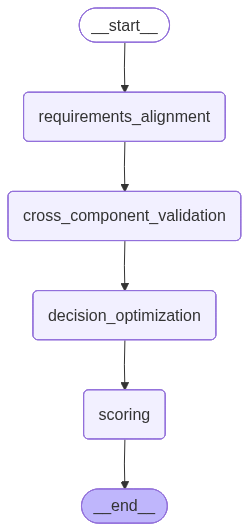

In [42]:
# ============ Graph Construction ===========

validation_graph = StateGraph(ValidationState)

validation_graph.add_node("requirements_alignment", requirements_alignment_node)
validation_graph.add_node("cross_component_validation", cross_component_node)
validation_graph.add_node("decision_optimization", decision_optimization_node)
validation_graph.add_node("scoring", scoring_node)

validation_graph.set_entry_point("requirements_alignment")
validation_graph.add_edge("requirements_alignment", "cross_component_validation")
validation_graph.add_edge("cross_component_validation", "decision_optimization")
validation_graph.add_edge("decision_optimization", "scoring")
validation_graph.add_edge("scoring", END)

validation_stage = validation_graph.compile()
validation_stage

In [28]:
report = validation_stage.invoke(common_validation_state)

In [ ]:
report["scoring_report"]

{'planning_confidence': 0.845,
 'design_confidence': 0.8800000000000001,
 'req_align_loss': 0.9,
 'cross_comp_loss': 0.6749999999999999,
 'optimization_loss': 0.9,
 'validation_score': 0.18999999999999995,
 'final_score': 0.39174999999999993}